# 168-Hour Load Forecasting: Tetouan City, Zones 1 to 3

**Headline finding: a tuned gradient-boosted model does not beat a seasonal-naive baseline
on this dataset at a 168-hour horizon.** This notebook shows the corrected setup and the
evidence for that conclusion.

**Dataset.** Power Consumption of Tetouan City, UCI Machine Learning Repository dataset 849.
Three urban distribution networks in northern Morocco (Quads, Smir, Boussafou substations,
operator Amendis), 10-minute readings through 2017, resampled to hourly. Source paper:
Salam and El Hibaoui, IEEE IRSEC 2018.

**Note on this notebook.** An earlier version reported that the model beat the naive baseline
in 9 of 9 combinations. That was an artifact of four defects, listed at the end. All modelling
code now lives in `src/forecasting.py` and `src/run_pipeline.py` so there is one source of
truth; this notebook imports it rather than restating it.

## 1. Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from forecasting import (ZONES, HORIZON, EMBARGO, TRAIN_CUTOFF, VAL_CUTOFF, FEATURES,
                         load_hourly, build_supervised_table, split, metrics,
                         baseline_metrics, effective_n, describe_split)

hdf = load_hourly("../data/processed/cleaned_energy_data.csv")
print(f"{len(hdf):,} hourly rows, {hdf.index.min()} to {hdf.index.max()}")
hdf.head()

8,736 hourly rows, 2017-01-01 00:00:00 to 2017-12-30 23:00:00


,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Temperature,Humidity
Datetime,,,,,
2017-01-01 00:00:00,29197.974683,18026.747720,19252.048193,6.196833,75.066667
2017-01-01 01:00:00,24657.215190,16078.419453,17042.891567,5.548833,77.583333
2017-01-01 02:00:00,22083.037973,14330.699088,15676.144578,5.054333,78.933333
2017-01-01 03:00:00,20811.139240,13219.452887,14883.855422,5.004333,77.083333
2017-01-01 04:00:00,20475.949367,12921.580547,14317.108433,5.097667,74.050000


**Finding.** 8,736 hourly rows covering 2017-01-01 to 2017-12-30 with no gaps. Three zone
series plus temperature and humidity.

## 2. Features

One row per (origin, horizon) pair, horizons 1 to 168. Every feature must be observable at
the forecast origin.

The critical detail is which lags are anchored to the **target** rather than the **origin**.
Because the horizon never exceeds 168, `target - 168` and `target - 336` are always at or
before the origin, so both are legal and both carry the value at the hour being predicted.
`lag24` must stay origin-anchored, since `target - 24` would fall in the future for horizons
beyond 24.

In [2]:
data = build_supervised_table(hdf, "PowerConsumption_Zone1")
print(f"{len(data):,} rows")
print("features:", FEATURES)

# observability assertions: no feature may draw on data after the origin
for name, offset in [("lag168", 168), ("lag336", 336)]:
    src_time = data["target_time"] - pd.Timedelta(hours=offset)
    assert (src_time <= data["origin_time"]).all(), name
    print(f"{name}: observable at origin for all rows -> OK")

data[["horizon", "origin_value", "lag168", "lag336", "seasonal_naive", "y"]].head()

1,382,976 rows
features: ['horizon', 'origin_value', 'lag24', 'lag168', 'lag336', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'roll_std_168', 'target_hour', 'target_dayofweek', 'target_month', 'target_is_weekend', 'weather_temp_lag168', 'weather_humidity_lag168']
lag168: observable at origin for all rows -> OK
lag336: observable at origin for all rows -> OK


,horizon,origin_value,lag168,lag336,seasonal_naive,y
0,1,25577.720703,23640.505859,24657.214844,23640.505859,19373.164062
1,2,25577.720703,21817.720703,22083.037109,21817.720703,17353.923828
2,3,25577.720703,20831.392578,20811.138672,20831.392578,16338.227539
3,4,25577.720703,20688.607422,20475.949219,20688.607422,15908.860352
4,5,25577.720703,21004.556641,20807.087891,21004.556641,16288.607422


**Finding.** Both weekly lags pass the observability assertion on every row, so no future
information enters the model. `lag168` and `seasonal_naive` are the same quantity: the value
at the same hour one week before the target. The model therefore receives the baseline's
answer as one of its inputs and can improve on it or not.

## 3. Splits, with a 168-hour embargo

Chronological, never random. The embargo matters: without it, a training row whose origin
sits just before the cutoff has targets reaching 168 hours past it, into the validation
period. The same happens at the validation-to-test boundary.

In [3]:
train, val, test = split(data)
display(describe_split(train, val, test))

assert train["target_time"].max() <= TRAIN_CUTOFF
assert val["target_time"].max() <= VAL_CUTOFF
assert test["target_time"].min() > VAL_CUTOFF
print("embargo holds: no split's targets reach into the next")

print(f"\ntest rows: {len(test):,}")
print(f"test effective n (distinct target hours): {effective_n(test):,}")
print(f"overstatement factor: {len(test)/effective_n(test):.0f}x")

,split,rows,origins,effective_n (distinct target hours),origin_first,origin_last,target_first,target_last
0,train,1044288,6216,6383,2017-01-15,2017-09-30 23:00:00,2017-01-15 01:00:00,2017-10-07 23:00:00
1,val,141120,840,1007,2017-10-08,2017-11-11 23:00:00,2017-10-08 01:00:00,2017-11-18 23:00:00
2,test,141120,840,1007,2017-11-19,2017-12-23 23:00:00,2017-11-19 01:00:00,2017-12-30 23:00:00


embargo holds: no split's targets reach into the next

test rows: 141,120
test effective n (distinct target hours): 1,007
overstatement factor: 140x


**Finding.** The embargo holds. Note the effective sample size: each target hour is forecast
from up to 168 different origins, so the raw row count overstates the evidence by about 140x.
Any confidence interval or significance test must use roughly 1,000, not 141,120.

## 4. Baselines

Two, both scored on exactly the same rows as the model.

| Baseline | Definition |
|---|---|
| Seasonal naive | `y[target - 168]`, same hour one week earlier |
| Persistence | `y[origin]`, the value at forecast time |

For a weekly-periodic series the seasonal naive is the appropriate baseline. Persistence is
included because the earlier version of this project was accidentally measuring it while
calling it a seasonal naive.

In [4]:
b = baseline_metrics(test)
pd.DataFrame(b).T[["MAPE", "MAE", "RMSE"]].round(2)

,MAPE,MAE,RMSE
seasonal_naive,2.86,813.96,1139.76
persistence,24.72,6926.19,8560.50


**Finding.** On Zone 1 the seasonal naive reaches 2.86% MAPE and persistence 24.72%. The gap
between them is the entire story of the original defect: the old code reported 24.57% and
called it a seasonal naive, which is persistence to within rounding.

## 5. Results

Model family and hyperparameters selected by FLAML AutoML on the validation split only
(300 seconds per zone, LightGBM / XGBoost / Random Forest / Extra Trees), then refit on
train plus validation with the configuration frozen and scored once on test.

Produced by `python src/run_pipeline.py 300`.

In [5]:
res = json.loads(Path("../reports/results_corrected.json").read_text(encoding="utf-8"))

rows = []
for z, v in res["zones"].items():
    rows.append({
        "Zone": z, "Model": v["model_family"],
        "Val MAPE %": round(v["val"]["MAPE"], 2),
        "Test MAPE %": round(v["test_refit"]["MAPE"], 2),
        "Seasonal naive %": round(v["baselines_test"]["seasonal_naive"]["MAPE"], 2),
        "Persistence %": round(v["baselines_test"]["persistence"]["MAPE"], 2),
        "Beats naive": v["beats_seasonal_naive_refit"],
    })
pd.DataFrame(rows)

,Zone,Model,Val MAPE %,Test MAPE %,Seasonal naive %,Persistence %,Beats naive
0,Zone 1,rf,6.24,4.20,2.86,24.72,False
1,Zone 2,rf,5.61,4.81,4.26,28.60,False
2,Zone 3,xgboost,7.33,20.64,8.73,28.35,False


**Finding.** The model beats persistence by a wide margin in all three zones, but loses to the
seasonal naive in all three. Zone 1 and Zone 2 are close (within 0.6 to 1.4 points). Zone 3 is
not close at all: 20.64% against an 8.73% baseline.

## 6. Walk-forward validation

In [6]:
mw = pd.DataFrame(res["multi_window"])
display(mw[["zone", "window", "period", "model_MAPE", "seasonal_naive_MAPE", "beats_seasonal_naive"]].round(2))
print(f"model beats seasonal naive in {mw['beats_seasonal_naive'].sum()}/{len(mw)} combinations")

,zone,window,period,model_MAPE,seasonal_naive_MAPE,beats_seasonal_naive
0,Zone 1,1,2017-11-18 to 2017-12-30,4.52,2.86,False
1,Zone 1,2,2017-10-07 to 2017-11-18,6.19,4.39,False
2,Zone 1,3,2017-08-26 to 2017-10-07,6.32,5.64,False
3,Zone 2,1,2017-11-18 to 2017-12-30,4.79,4.26,False
4,Zone 2,2,2017-10-07 to 2017-11-18,5.53,5.06,False
5,Zone 2,3,2017-08-26 to 2017-10-07,9.36,9.11,False
6,Zone 3,1,2017-11-18 to 2017-12-30,22.10,8.73,False
7,Zone 3,2,2017-10-07 to 2017-11-18,9.09,10.08,True
8,Zone 3,3,2017-08-26 to 2017-10-07,18.11,10.92,False


model beats seasonal naive in 1/9 combinations


**Finding.** 1 of 9. The single win is Zone 3 window 2, which is the validation period the
hyperparameters were selected on, so it is optimistic by construction and should not count as
evidence of skill. The honest reading is 0 of 8 on genuinely held-out windows.

## 7. Where the model loses

Per-hour error on Zone 1 explains why. The model is beaten most at 06:00, 17:00 and 20:00,
the two daily ramps and the evening peak, and wins only in the flat midday hours.

A model that predicts the load level must reconstruct the weekly shape from calendar
features, and averaging many weeks smooths the sharp ramps. The seasonal naive copies one
real week, so the ramps keep their true steepness.

In [7]:
import joblib
m = joblib.load("../models/zone_1_final_refit_trainval.joblib")
t = test.copy()
t["pred"] = m.predict(t[FEATURES])

by_hour = t.groupby("target_hour").apply(lambda x: pd.Series({
    "actual mean kW": x["y"].mean(),
    "model MAPE %": (abs(x["pred"] - x["y"]) / x["y"]).mean() * 100,
    "snaive MAPE %": (abs(x["seasonal_naive"] - x["y"]) / x["y"]).mean() * 100,
}), include_groups=False).round(2)
by_hour.loc[[0, 6, 12, 14, 17, 20, 23]]

,actual mean kW,model MAPE %,snaive MAPE %
target_hour,,,
0,25689.92,2.29,1.86
6,22399.82,2.81,2.50
12,31320.78,4.32,4.01
14,30796.42,4.01,4.11
17,36580.38,3.46,2.84
20,38470.34,4.23,1.56
23,29438.93,5.61,1.83


**Finding.** The model loses at 22 of the 24 hours, winning only at 01:00 and 14:00 and tying at 13:00. The widest gaps are the small hours and late evening: 04:00 (6.33% vs 2.09%), 23:00 (5.61% vs 1.83%), 03:00 (5.90% vs 2.21%) and 19:00 (5.32% vs 1.86%).

Those are the most repeatable hours of the week, which is exactly where copying last week is hardest to improve on. The model is closest during the daytime hours, where week-to-week variation is larger and calendar structure carries more information. This is the signature of a model reproducing an average weekly profile rather than tracking recent conditions.

## 8. Figures

Generated by `python src/make_figures.py`. Every chart plots both baselines so none can imply
an improvement measured against a strawman.

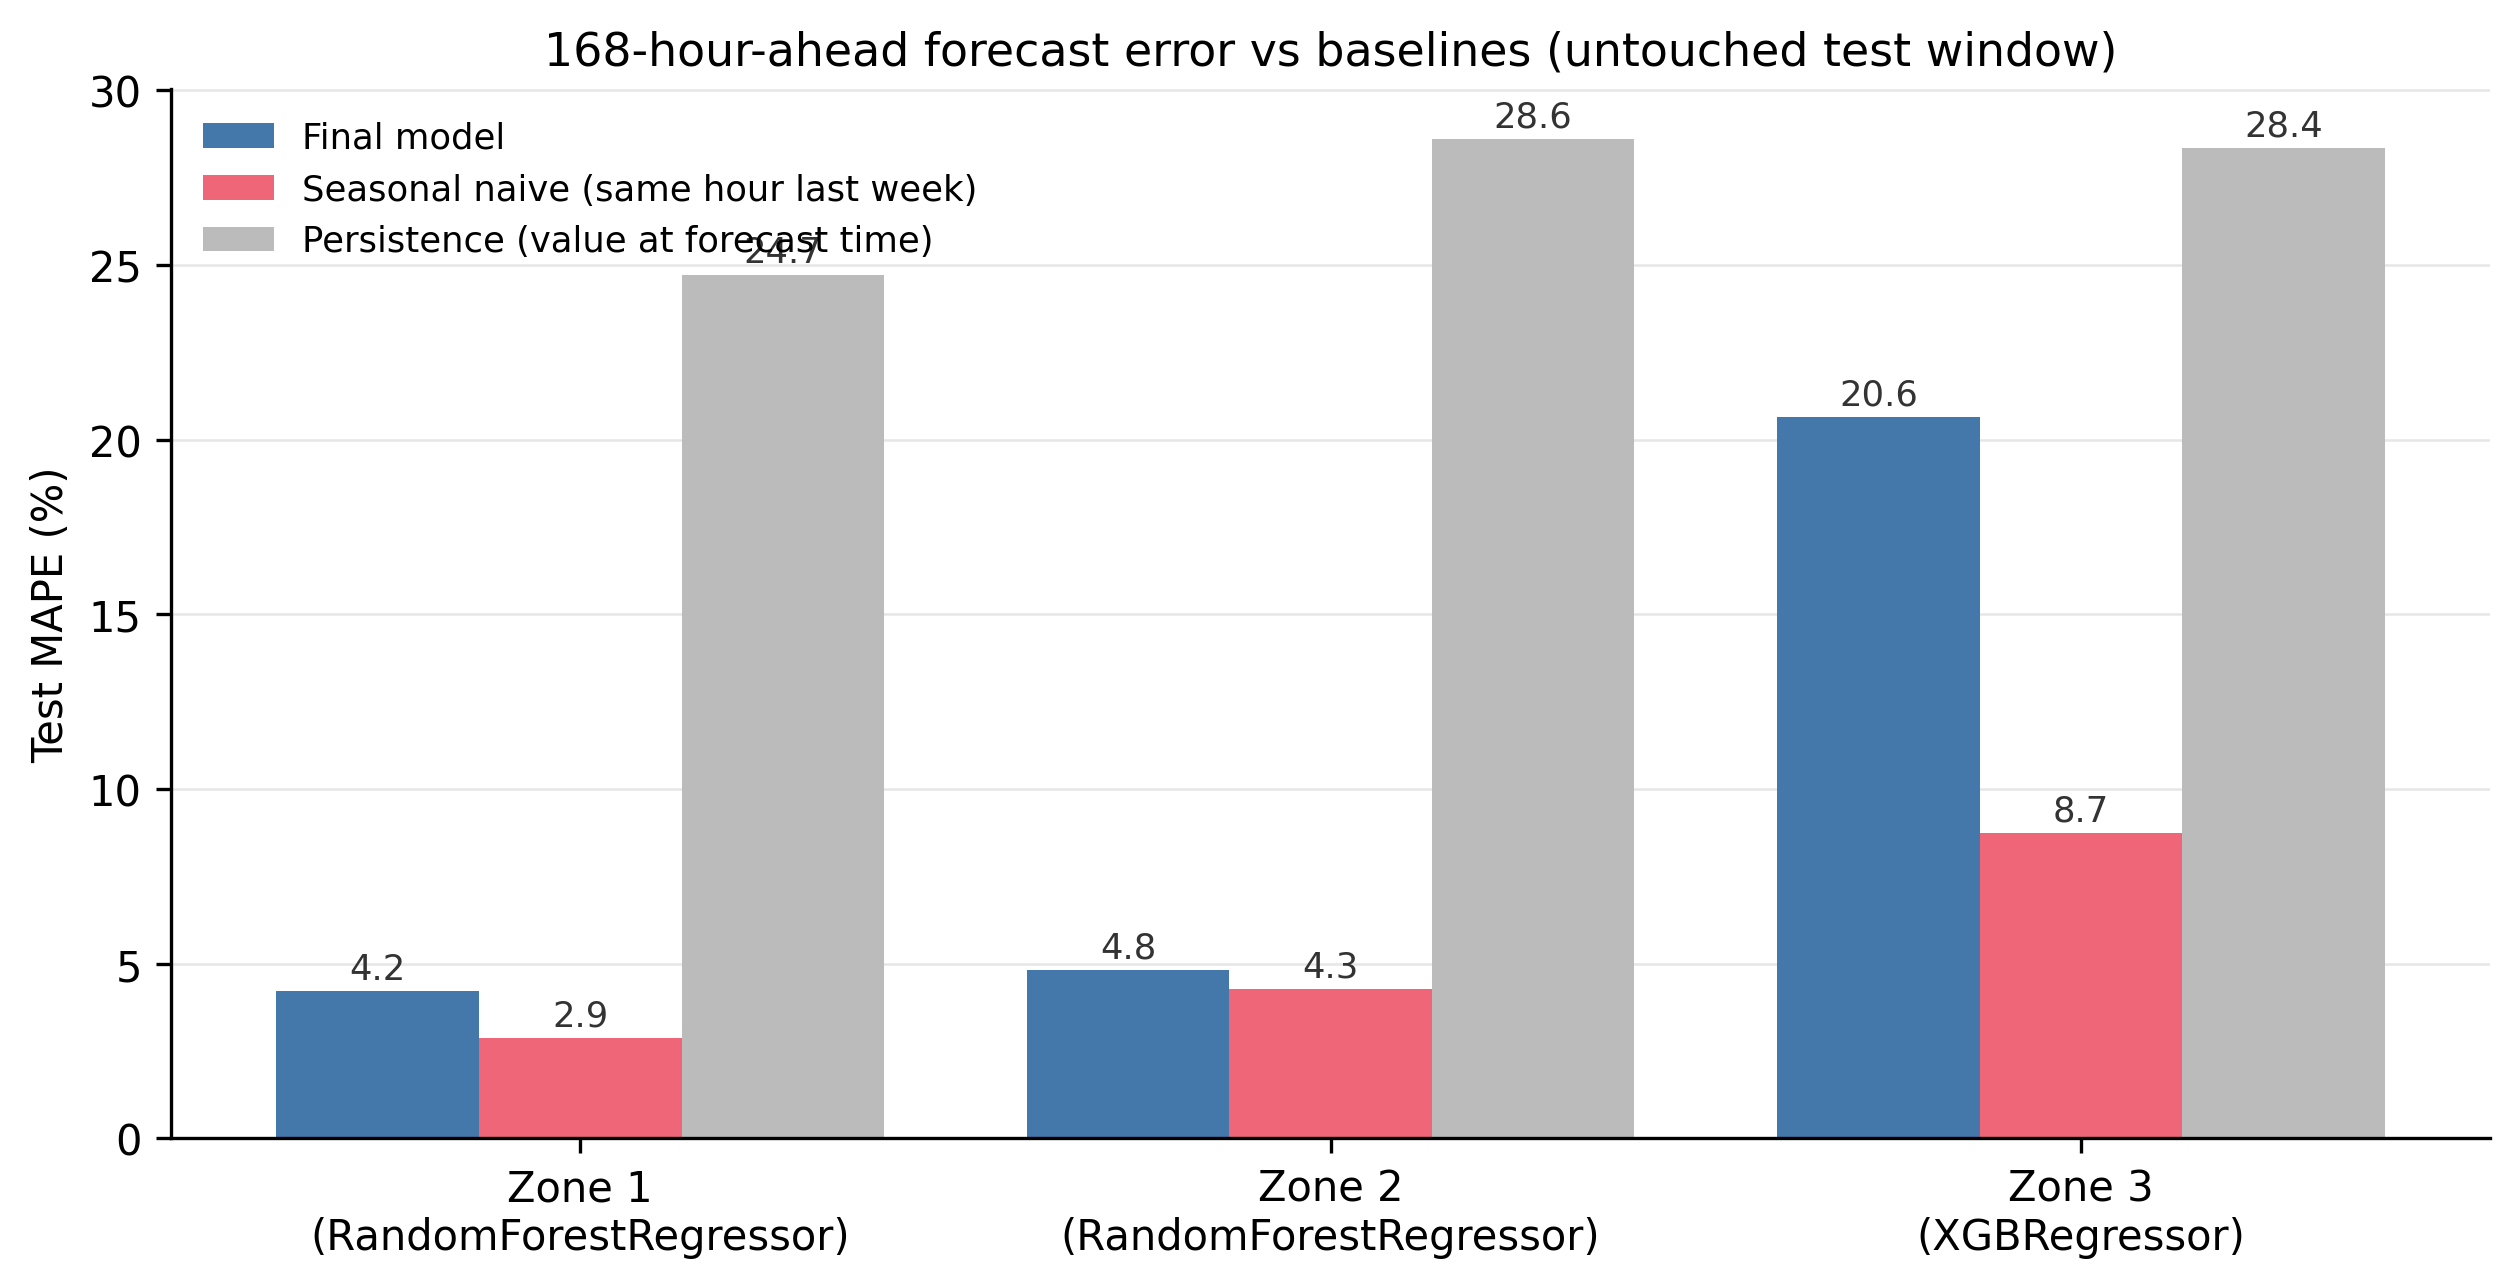

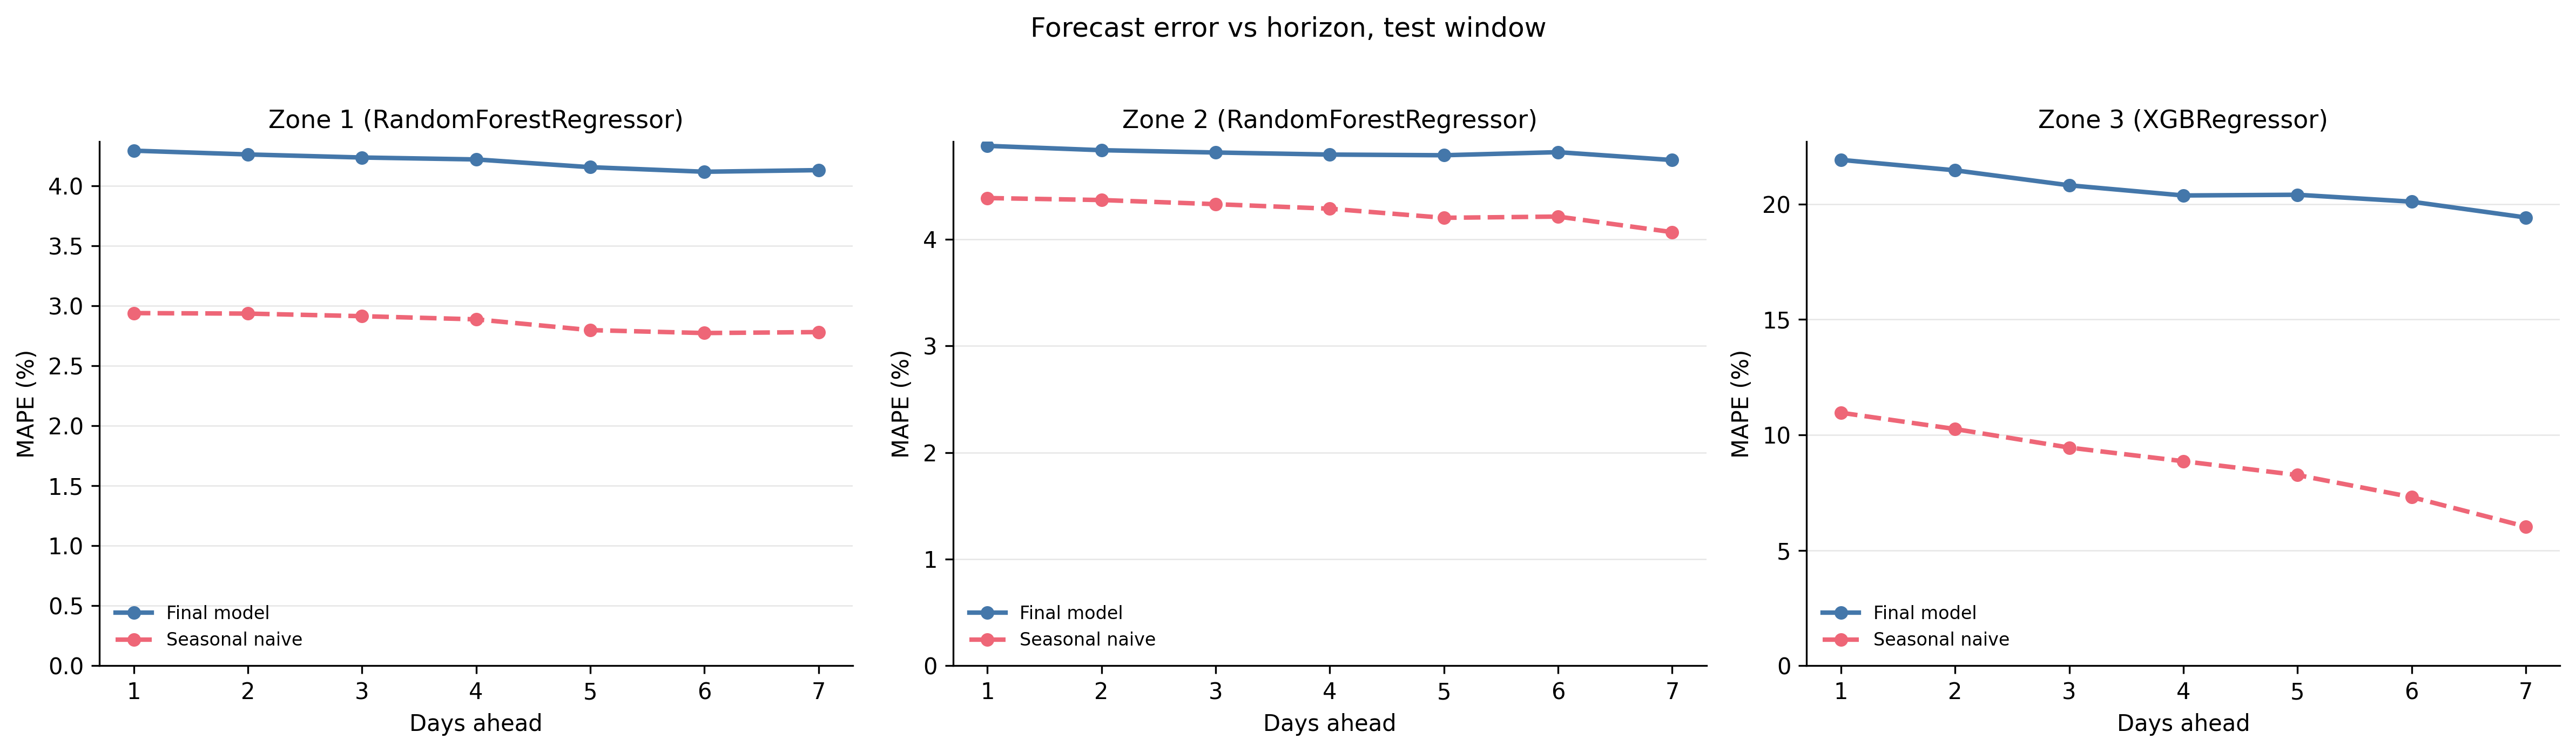

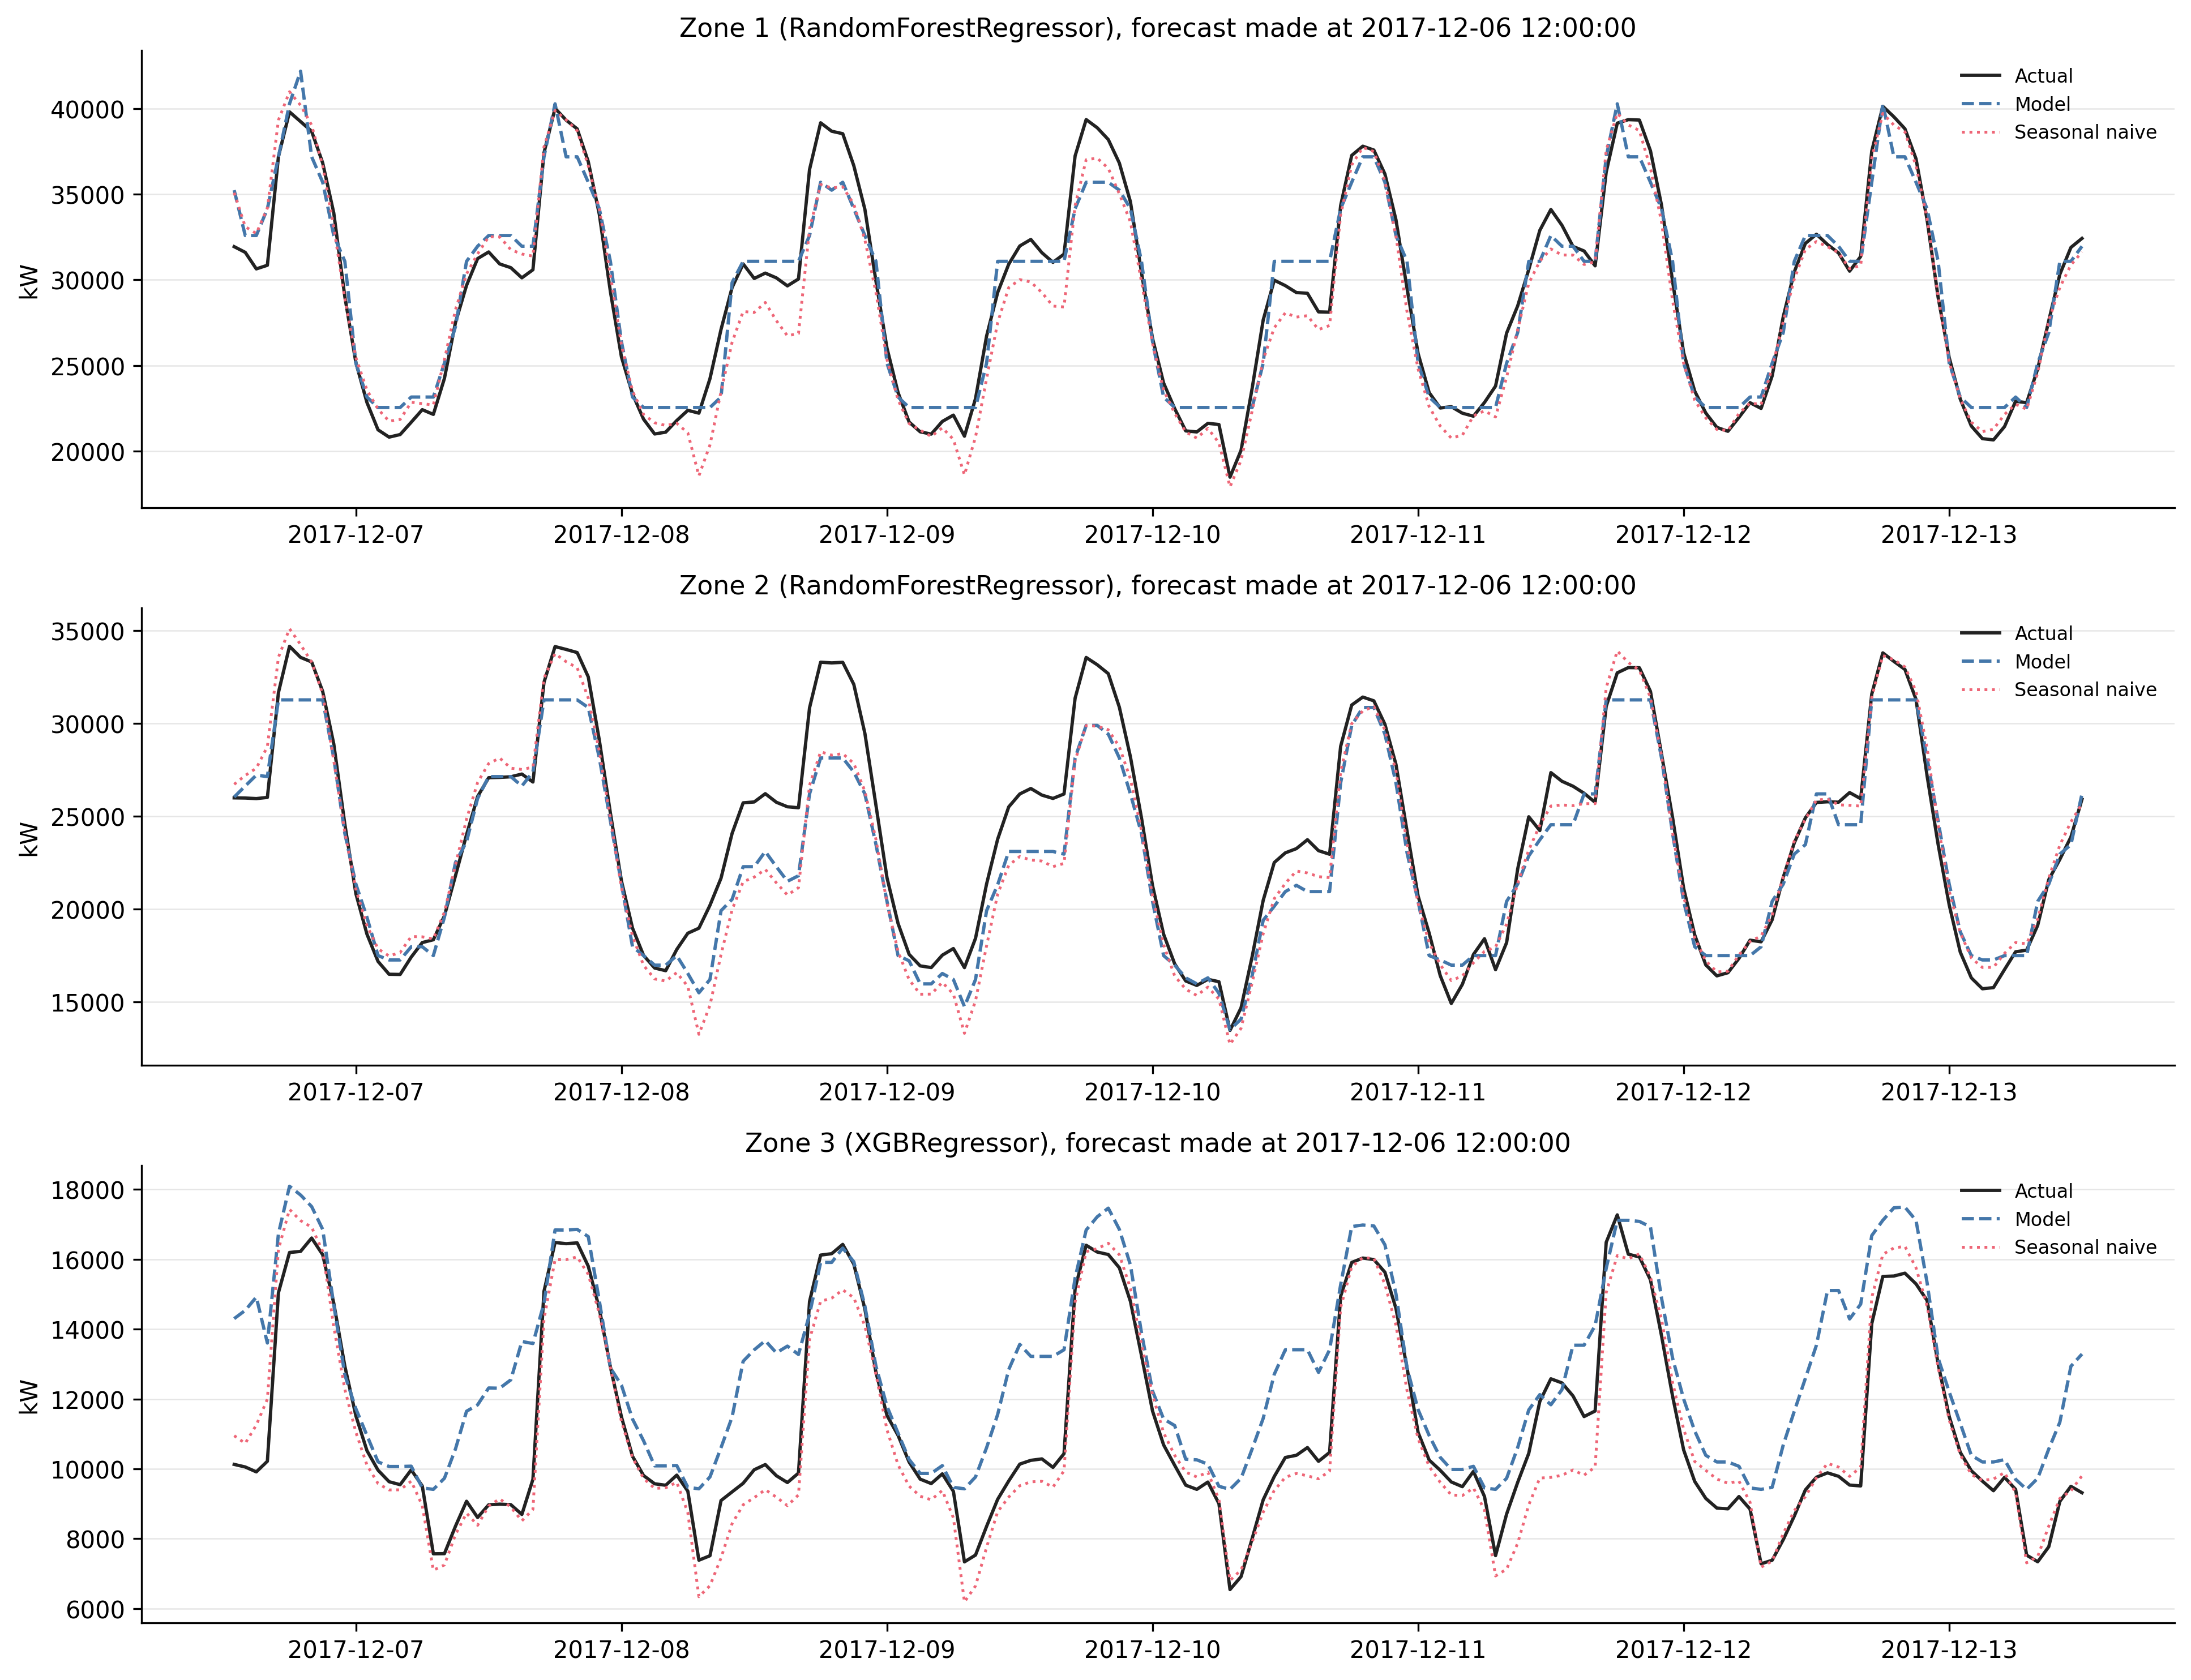

In [8]:
from IPython.display import Image, display
for f in ["final_headline_model_vs_naive", "final_error_vs_horizon", "final_sample_forecasts"]:
    display(Image(filename=f"../reports/figures/modeling/{f}.png", width=900))

## 9. Corrections applied in September 2026

An audit of this project found four defects. All are fixed, and
`python src/validate_project.py` now asserts each so they cannot recur silently.

1. **`lag168` was anchored to the origin** rather than the target. The model received one
   frozen value from the origin's hour of day for all 168 predictions, so it could only learn
   an average weekly shape. The weather lag was already target-anchored; the power lag should
   have been too.
2. **The naive baseline used the same wrong index**, making it a strawman at about 25% MAPE.
   It was measuring persistence, not a seasonal naive.
3. **No embargo between splits.** Training targets reached into validation, validation targets
   into test.
4. **Sample size overstated about 140x** by reporting rows rather than distinct target hours.

The previous headline, "beats naive in 9 of 9 by 47 to 85 percent," was entirely an artifact of
defects 1 and 2 and has been withdrawn.

A symptom was visible and misread at the time: error was flat at 3.60 to 3.62 percent from day 1
to day 7. Forecast error grows with horizon, so flat error meant the model was ignoring recent
information. It was written up as a strength.

## Limitations

- The model does not beat a seasonal naive at this horizon. Reported as the result.
- Zone 3 is unstable, 20.64% on test and 22.10% and 18.11% on two of three windows.
- Single year of data, so seasonal effects are observed once.
- 300-second AutoML budget per zone. A longer search might narrow the gap; it was not run.
- Untested directions that could change the conclusion: multiple seasonal lags, holiday flags,
  per-horizon models, probabilistic rather than point forecasts.

## Follow-up experiments

Three further studies, all in `src/` with results in `reports/*.json`:

- **Horizon** (`horizon_experiment.py`): the model wins only at 1 hour ahead, and loses from 6 hours out. The seasonal naive is nearly horizon-independent on a weekly-periodic series, so a longer horizon penalises the model but not the baseline.
- **Feature ceiling** (`ceiling_experiment.py`): legal level-shift features change nothing, and an oracle weather forecast (unavailable at forecast time, reported only as an upper bound) makes every zone slightly worse. The design was not handicapped by using lagged rather than forecast weather.
- **Combination and significance** (`combination_experiment.py`, `significance_test.py`): blending model and baseline produced apparent gains of 0.03 and 0.13 pp on Zones 1 and 2, but with errors collapsed to one per target hour (effective n = 1,007) a Diebold-Mariano test gives p = 0.83 and 0.84. Those gains are not distinguishable from zero.

**Final statement.** The model alone is significantly worse than a seasonal naive in all three zones (p = 0.0008, 0.024, <0.0001). Blending brings Zones 1 and 2 to statistical parity and never beats the baseline.